In [1]:
import yaml
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import math
import os
import glob
import pdb

from utils import make_model, set_random_seed
from trainer import eval_metrics
from dataset import load_data
from dataset_config import DATASET_CONFIG

import pdb


DATASET_CONFIG = {
    'new_tetronimoes': {
        'x_train_path': "/data/datasets/new_tetrominoes/train_images.npy", # WRITE ABSOLUTE PATHS
        'y_train_path': "/data/datasets/new_tetrominoes/train_masks.npy",
        'x_val_path': "/data/datasets/new_tetrominoes/val_images.npy",
        'y_val_path': "/data/datasets/new_tetrominoes/val_masks.npy",
        'x_test_path': "/data/datasets/new_tetrominoes/test_images.npy",
        'y_test_path': "/data/datasets/new_tetrominoes/test_masks.npy",
        'img_size': 64,
        'channels': 3,
    },
    'multi_mnist': {
        'x_train_path': "/n/ba_lab/Everyone/mjacobs/data/datasets/multi_mnist/train_images.npy",
        'y_train_path': "/n/ba_lab/Everyone/mjacobs/data/datasets/multi_mnist/train_masks.npy",
        'x_val_path': "/n/ba_lab/Everyone/mjacobs/data/datasets/multi_mnist/val_images.npy",
        'y_val_path': "/n/ba_lab/Everyone/mjacobs/data/datasets/multi_mnist/val_masks.npy",
        'x_test_path': "/n/ba_lab/Everyone/mjacobs/data/datasets/multi_mnist/test_images.npy",
        'y_test_path': "/n/ba_lab/Everyone/mjacobs/data/datasets/multi_mnist/test_masks.npy",
        'img_size': 128,
        'channels': 1,
    },
    'mnist': {
        'train_path': '/data/datasets/mnist/',
        'test_path': '/data/datasets/mnist/',
        'img_size': 56,  # Image size for resizing
        'channels': 1, # originally 1, but color jitter makes it 3
    },
}

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load data
data_config1 = DATASET_CONFIG['multi_mnist']
_, valset, _ = load_data('multi_mnist', data_config1)

In [8]:
x, y = valset.x, valset.labels

In [9]:
x.shape, y.shape

(torch.Size([1000, 1, 128, 128]), torch.Size([1000, 128, 128]))

In [10]:
x = x.numpy().reshape(x.size(0), 128, 128)
y = y.numpy()

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
sns.set_theme()

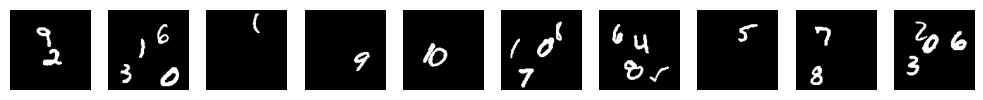

In [18]:
fig, axes = plt.subplots(1, 10, figsize=(10, 4))
for i in range(10):
    axes[i].imshow(x[i], cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [19]:
fig, axes = plt.subplots(1, 10, figsize=(10, 4))
for i in range(10):
    axes[i].imshow(x[i], cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.savefig("results_scores/multi_mnist_example.pdf", dpi=300)
plt.close()